### Dataset: Energy Efficiency with CL (cooling load) as target

In [1]:
from ucimlrepo import fetch_ucirepo

energy_efficiency = fetch_ucirepo(id=242) 
  
X = energy_efficiency.data.features 
y = energy_efficiency.data.targets

var_df = energy_efficiency.variables
col_map = dict(zip(var_df["name"], var_df["description"]))
X = X.rename(columns=col_map)
y = y.rename(columns=col_map)

y = y[["Cooling Load"]]
df = X.join(y)
df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Cooling Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,28.28


### Train test split

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,     
    random_state=42,   
    shuffle=True
)

print(f"#X_train = {len(X_train)}   #y_train = {len(y_train)}")
print(f"#X_test = {len(X_test)}     #y_test = {len(y_test)}")

#X_train = 691   #y_train = 691
#X_test = 77     #y_test = 77


### EDF normalization

In [3]:
from src.edf import edf_normalize, col_denorm

X_train_norm, X_test_norm, _ = edf_normalize(X_train, X_test)
y_train_norm, y_test_norm, edf_models = edf_normalize(y_train, y_test)

y_denorm = col_denorm("Cooling Load", edf_models)

 ### Novelty (feature deg. 4, target deg. 4)

In [ ]:
from src.evaluation import novelty, report_novelty

columns_novelty = {}
for col in X.columns:
    print(f"--- Evaluating novelty for feature: {col} ---")
    softplus_novelty = novelty(X_train_norm, X_test_norm,
                                   y_train_norm, y_test_norm,
                                   col, y_test, y_denorm,   
                                   N_feature=4, N_target=4)

    param_softplus_novelty = novelty(X_train_norm, X_test_norm,
                                         y_train_norm, y_test_norm,
                                         col, y_test, y_denorm,
                                         N_feature=4, N_target=4,
                                         method="softplus", a=3., b=100.)

    clip_novelty = novelty(X_train_norm, X_test_norm,
                               y_train_norm, y_test_norm,
                               col, y_test, y_denorm,  
                               N_feature=4, N_target=4,
                               method="clip")

    columns_novelty[col] = {
        "softplus": softplus_novelty,
        "param-softplus": param_softplus_novelty,
        "clip": clip_novelty
    }

In [5]:
report_novelty(columns_novelty, method="softplus")

Feature Novelty Ranking (method: softplus):
1. Roof Area: 0.0605
2. Glazing Area: 0.0417
3. Wall Area: 0.0379
4. Relative Compactness: 0.0097
5. Surface Area: 0.0044
6. Overall Height: 0.0003
7. Glazing Area Distribution: -0.0013
8. Orientation: -0.0019


In [6]:
report_novelty(columns_novelty, method="param-softplus")

Feature Novelty Ranking (method: param-softplus):
1. Glazing Area: 0.1030
2. Roof Area: 0.0932
3. Wall Area: 0.0252
4. Relative Compactness: 0.0128
5. Surface Area: 0.0060
6. Overall Height: 0.0000
7. Orientation: -0.0020
8. Glazing Area Distribution: -0.0052


In [7]:
report_novelty(columns_novelty, method="clip")

Feature Novelty Ranking (method: clip):
1. Roof Area: 0.0775
2. Wall Area: 0.0548
3. Glazing Area: 0.0256
4. Relative Compactness: 0.0121
5. Surface Area: 0.0050
6. Overall Height: 0.0003
7. Glazing Area Distribution: -0.0022
8. Orientation: -0.0033


In [8]:
import pandas as pd

df_novelty = pd.DataFrame.from_dict(
    columns_novelty,
    orient="index"
)
df_novelty

,softplus,param-softplus,clip
Relative Compactness,0.009707,0.012846,0.012130
Surface Area,0.004432,0.006009,0.004993
Wall Area,0.037910,0.025221,0.054773
Roof Area,0.060455,0.093224,0.077463
Overall Height,0.000309,0.000042,0.000250
Orientation,-0.001880,-0.001962,-0.003274
Glazing Area,0.041722,0.103020,0.025602
Glazing Area Distribution,-0.001319,-0.005212,-0.002163


 ### CV for novelty (feature deg. 4, target deg. 4)

In [ ]:
from src.cv import cv_novelty, print_cv_novelty, plot_cv_novelty
softplus_results = cv_novelty(X, y,
                              N_feature=4, N_target=4)

CV Novelty Results (method: softplus):

Feature: Relative Compactness
  per fold: [0.01 0.01 0.   0.01 0.01 0.   0.01 0.   0.01 0.  ]
  mean novelty : 0.0047
  std novelty  : 0.0018

Feature: Surface Area
  per fold: [ 0.  0.  0. -0.  0.  0.  0.  0.  0.  0.]
  mean novelty : 0.0012
  std novelty  : 0.0013

Feature: Wall Area
  per fold: [0.07 0.03 0.04 0.03 0.02 0.03 0.03 0.04 0.04 0.05]
  mean novelty : 0.0377
  std novelty  : 0.0139

Feature: Roof Area
  per fold: [0.07 0.05 0.04 0.06 0.03 0.06 0.06 0.01 0.04 0.04]
  mean novelty : 0.0457
  std novelty  : 0.0155

Feature: Overall Height
  per fold: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  mean novelty : 0.0006
  std novelty  : 0.0005

Feature: Orientation
  per fold: [ 0. -0.  0. -0. -0. -0. -0. -0.  0. -0.]
  mean novelty : -0.0010
  std novelty  : 0.0010

Feature: Glazing Area
  per fold: [0.05 0.07 0.06 0.05 0.06 0.06 0.05 0.05 0.05 0.05]
  mean novelty : 0.0544
  std novelty  : 0.0082

Feature: Glazing Area Distribution
  per fold: [ 0.

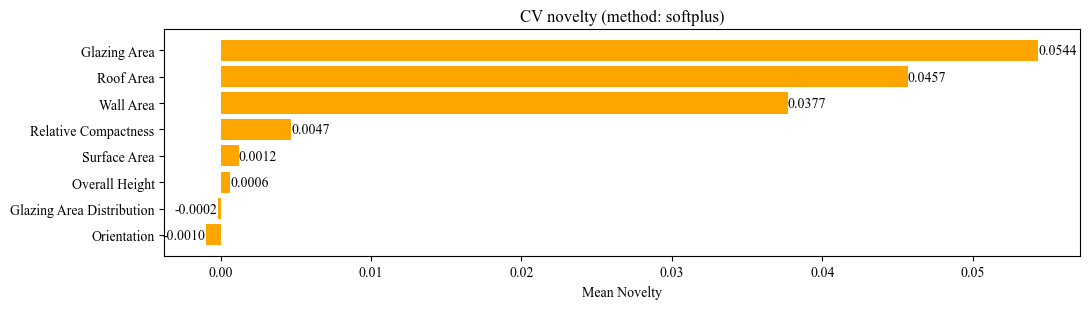

In [10]:
print_cv_novelty(softplus_results, X.columns)
plot_cv_novelty(softplus_results, X.columns)

In [ ]:
from src.cv import cv_novelty, print_cv_novelty, plot_cv_novelty
param_softplus_results = cv_novelty(X, y,
                                    N_feature=4, N_target=4,
                                    method="softplus", a=3., b=100.)

CV Novelty Results (method: param-softplus):

Feature: Relative Compactness
  per fold: [ 0.01  0.01  0.    0.    0.01  0.    0.01  0.    0.   -0.  ]
  mean novelty : 0.0045
  std novelty  : 0.0032

Feature: Surface Area
  per fold: [ 0.01  0.   -0.   -0.    0.   -0.    0.   -0.    0.    0.  ]
  mean novelty : 0.0012
  std novelty  : 0.0030

Feature: Wall Area
  per fold: [ 0.08  0.03  0.02  0.01  0.03 -0.01  0.03  0.04  0.05  0.04]
  mean novelty : 0.0333
  std novelty  : 0.0225

Feature: Roof Area
  per fold: [ 0.09  0.08  0.07  0.12  0.04  0.12  0.11 -0.    0.06  0.04]
  mean novelty : 0.0728
  std novelty  : 0.0385

Feature: Overall Height
  per fold: [ 0. -0. -0.  0.  0. -0.  0.  0.  0. -0.]
  mean novelty : 0.0004
  std novelty  : 0.0009

Feature: Orientation
  per fold: [-0.   -0.   -0.   -0.    0.    0.   -0.01 -0.   -0.   -0.  ]
  mean novelty : -0.0020
  std novelty  : 0.0020

Feature: Glazing Area
  per fold: [0.08 0.21 0.17 0.11 0.12 0.12 0.14 0.15 0.12 0.14]
  mean novelty

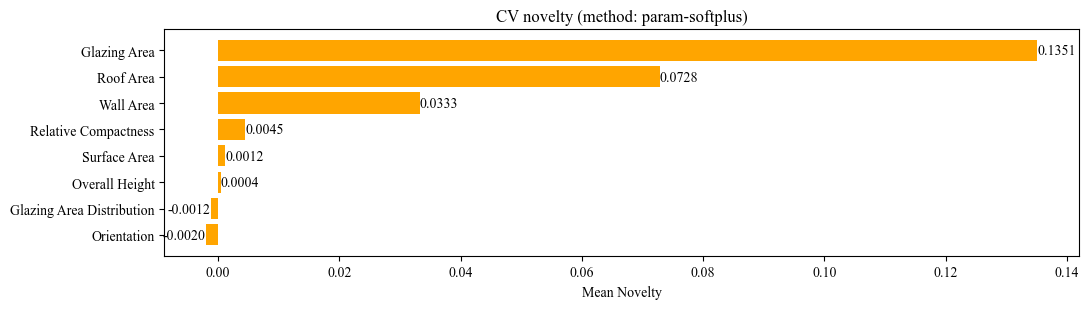

In [12]:
print_cv_novelty(param_softplus_results, X.columns, method="param-softplus")
plot_cv_novelty(param_softplus_results, X.columns, method="param-softplus")

In [ ]:
from src.cv import cv_novelty, print_cv_novelty, plot_cv_novelty
clip_results = cv_novelty(X, y,
                          N_feature=4, N_target=4,
                          method="clip")

CV Novelty Results (method: clip):

Feature: Relative Compactness
  per fold: [ 0.01  0.01  0.    0.01  0.01  0.    0.01  0.    0.01 -0.  ]
  mean novelty : 0.0054
  std novelty  : 0.0032

Feature: Surface Area
  per fold: [ 0.  0.  0. -0.  0.  0.  0.  0.  0.  0.]
  mean novelty : 0.0013
  std novelty  : 0.0016

Feature: Wall Area
  per fold: [ 0.09  0.04  0.05  0.04 -0.11  0.04  0.04  0.05  0.06  0.05]
  mean novelty : 0.0346
  std novelty  : 0.0515

Feature: Roof Area
  per fold: [ 0.08  0.07  0.06  0.08 -0.09  0.08  0.07  0.01  0.05  0.03]
  mean novelty : 0.0439
  std novelty  : 0.0507

Feature: Overall Height
  per fold: [ 0. -0.  0.  0.  0.  0.  0.  0.  0.  0.]
  mean novelty : 0.0007
  std novelty  : 0.0006

Feature: Orientation
  per fold: [ 0. -0. -0. -0. -0. -0. -0. -0. -0. -0.]
  mean novelty : -0.0013
  std novelty  : 0.0011

Feature: Glazing Area
  per fold: [0.03 0.06 0.05 0.02 0.04 0.05 0.04 0.02 0.03 0.03]
  mean novelty : 0.0367
  std novelty  : 0.0115

Feature: Glazin

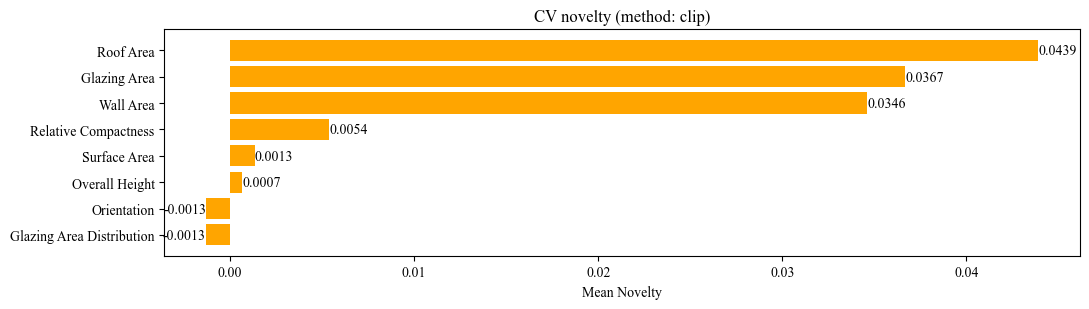

In [14]:
print_cv_novelty(clip_results, X.columns, method="clip")
plot_cv_novelty(clip_results, X.columns, method="clip")

In [15]:
from src.evaluation import novelty_to_df
novelty_df = novelty_to_df(softplus_results,
                           param_softplus_results,
                           clip_results)
novelty_df

softplus           param_softplus            \
                               mean       std           mean       std   
feature                                                                  
Relative Compactness       0.004707  0.001845       0.004482  0.003216   
Surface Area               0.001202  0.001312       0.001192  0.003015   
Wall Area                  0.037698  0.013935       0.033268  0.022489   
Roof Area                  0.045682  0.015465       0.072804  0.038460   
Overall Height             0.000634  0.000479       0.000406  0.000935   
Orientation               -0.000975  0.001004      -0.002048  0.001993   
Glazing Area               0.054361  0.008167       0.135135  0.034042   
Glazing Area Distribution -0.000195  0.002435      -0.001207  0.006573   

                               clip            
                               mean       std  
feature                                        
Relative Compactness       0.005380  0.003222  
Surface Area               0.001348  0.001569  
Wall Area                  0.034625  0.051534  
Roof Area                  0.043909  0.050678  
Overall Height             0.000651  0.000564  
Orientation               -0.001306  0.001108  
Glazing Area               0.036688  0.011491  
Glazing Area Distribution -0.001318  0.003192

 ### Novelty (feature deg. 7, target deg. 8)

In [ ]:
from src.evaluation import novelty, report_novelty

columns_novelty_higher_degs = {}
for col in X.columns:
    print(f"--- Evaluating novelty for feature: {col} ---")
    softplus_novelty = novelty(X_train_norm, X_test_norm,
                               y_train_norm, y_test_norm,
                               col, y_test, y_denorm,   
                               N_feature=7, N_target=8)

    param_softplus_novelty = novelty(X_train_norm, X_test_norm,
                                     y_train_norm, y_test_norm,
                                     col, y_test, y_denorm,
                                     N_feature=7, N_target=8,
                                     method="softplus", a=3., b=100.)

    clip_novelty = novelty(X_train_norm, X_test_norm,
                           y_train_norm, y_test_norm,
                           col, y_test, y_denorm,  
                           N_feature=7, N_target=8,
                           method="clip")

    columns_novelty_higher_degs[col] = {
        "softplus": softplus_novelty,
        "param-softplus": param_softplus_novelty,
        "clip": clip_novelty
    }

In [17]:
report_novelty(columns_novelty_higher_degs, method="softplus")

Feature Novelty Ranking (method: softplus):
1. Glazing Area: 0.1052
2. Wall Area: 0.0091
3. Relative Compactness: 0.0015
4. Surface Area: 0.0011
5. Overall Height: 0.0002
6. Roof Area: 0.0001
7. Orientation: -0.0046
8. Glazing Area Distribution: -0.0057


In [18]:
report_novelty(columns_novelty_higher_degs, method="param-softplus")

Feature Novelty Ranking (method: param-softplus):
1. Glazing Area: 0.3131
2. Wall Area: 0.0059
3. Overall Height: 0.0002
4. Roof Area: -0.0001
5. Surface Area: -0.0002
6. Relative Compactness: -0.0007
7. Orientation: -0.0045
8. Glazing Area Distribution: -0.0142


In [19]:
report_novelty(columns_novelty_higher_degs, method="clip")

Feature Novelty Ranking (method: clip):
1. Glazing Area: 0.0656
2. Wall Area: 0.0080
3. Relative Compactness: 0.0016
4. Surface Area: 0.0012
5. Roof Area: 0.0002
6. Overall Height: 0.0002
7. Orientation: -0.0058
8. Glazing Area Distribution: -0.0059


In [20]:
import pandas as pd

df_novelty = pd.DataFrame.from_dict(
    columns_novelty_higher_degs,
    orient="index"
)
df_novelty

,softplus,param-softplus,clip
Relative Compactness,0.001500,-0.000678,0.001577
Surface Area,0.001065,-0.000196,0.001237
Wall Area,0.009100,0.005887,0.007956
Roof Area,0.000091,-0.000080,0.000232
Overall Height,0.000226,0.000208,0.000174
Orientation,-0.004601,-0.004458,-0.005819
Glazing Area,0.105201,0.313142,0.065562
Glazing Area Distribution,-0.005689,-0.014225,-0.005936


 ### CV for novelty (feature deg. 7, target deg. 8)

In [ ]:
from src.cv import cv_novelty, print_cv_novelty, plot_cv_novelty
softplus_results_higher_degs = cv_novelty(X, y,
                                          N_feature=7, N_target=8)

CV Novelty Results (method: softplus):

Feature: Relative Compactness
  per fold: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  mean novelty : 0.0014
  std novelty  : 0.0005

Feature: Surface Area
  per fold: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  mean novelty : 0.0010
  std novelty  : 0.0003

Feature: Wall Area
  per fold: [ 0.01  0.02  0.01  0.01  0.   -0.    0.    0.   -0.    0.01]
  mean novelty : 0.0047
  std novelty  : 0.0056

Feature: Roof Area
  per fold: [-0.  0.  0. -0. -0. -0. -0. -0. -0.  0.]
  mean novelty : -0.0001
  std novelty  : 0.0003

Feature: Overall Height
  per fold: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  mean novelty : 0.0002
  std novelty  : 0.0001

Feature: Orientation
  per fold: [-0.   -0.   -0.01 -0.01 -0.   -0.   -0.01 -0.    0.   -0.  ]
  mean novelty : -0.0036
  std novelty  : 0.0022

Feature: Glazing Area
  per fold: [0.13 0.15 0.15 0.1  0.1  0.15 0.12 0.13 0.11 0.14]
  mean novelty : 0.1287
  std novelty  : 0.0191

Feature: Glazing Area Distribution
  per fold: [-0.01 -0.   

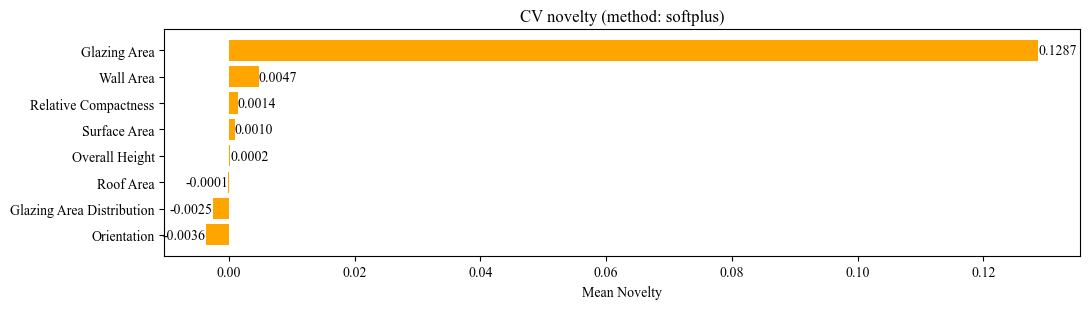

In [22]:
print_cv_novelty(softplus_results_higher_degs, X.columns)
plot_cv_novelty(softplus_results_higher_degs, X.columns)

In [ ]:
from src.cv import cv_novelty, print_cv_novelty, plot_cv_novelty
param_softplus_results_higher_degs = cv_novelty(X, y,
                                                N_feature=7, N_target=8,
                                                method="softplus", a=3., b=100.)

CV Novelty Results (method: param-softplus):

Feature: Relative Compactness
  per fold: [-0. -0. -0.  0.  0.  0.  0.  0. -0.  0.]
  mean novelty : -0.0002
  std novelty  : 0.0019

Feature: Surface Area
  per fold: [ 0.  0. -0.  0.  0.  0.  0. -0. -0.  0.]
  mean novelty : 0.0001
  std novelty  : 0.0010

Feature: Wall Area
  per fold: [ 0.02  0.03  0.01  0.01  0.   -0.02  0.    0.   -0.01  0.  ]
  mean novelty : 0.0024
  std novelty  : 0.0127

Feature: Roof Area
  per fold: [-0. -0. -0. -0. -0. -0. -0. -0. -0.  0.]
  mean novelty : -0.0009
  std novelty  : 0.0009

Feature: Overall Height
  per fold: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  mean novelty : 0.0005
  std novelty  : 0.0003

Feature: Orientation
  per fold: [-0.   -0.01 -0.02 -0.01 -0.   -0.01 -0.01 -0.   -0.   -0.01]
  mean novelty : -0.0078
  std novelty  : 0.0048

Feature: Glazing Area
  per fold: [0.26 0.34 0.33 0.29 0.19 0.31 0.27 0.36 0.25 0.34]
  mean novelty : 0.2940
  std novelty  : 0.0499

Feature: Glazing Area Distributio

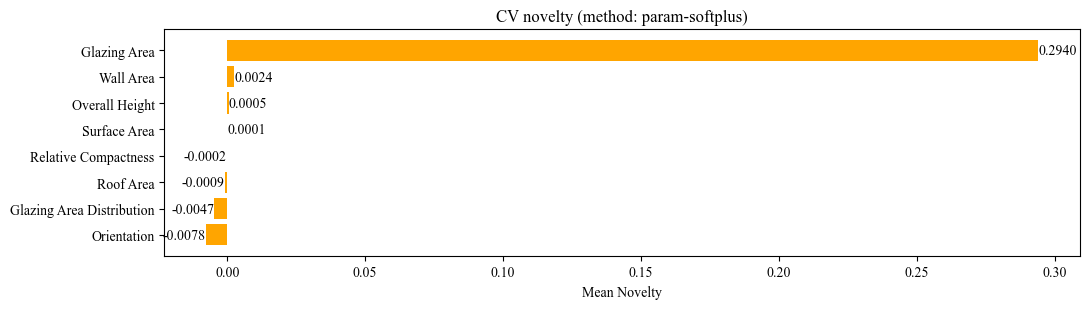

In [24]:
print_cv_novelty(param_softplus_results_higher_degs, X.columns, method="param-softplus")
plot_cv_novelty(param_softplus_results_higher_degs, X.columns, method="param-softplus")

In [ ]:
from src.cv import cv_novelty, print_cv_novelty, plot_cv_novelty
clip_results_higher_degs = cv_novelty(X, y,
                                      N_feature=7, N_target=8,
                                      method="clip")

CV Novelty Results (method: clip):

Feature: Relative Compactness
  per fold: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  mean novelty : 0.0012
  std novelty  : 0.0007

Feature: Surface Area
  per fold: [ 0.  0. -0.  0.  0.  0.  0.  0. -0.  0.]
  mean novelty : 0.0006
  std novelty  : 0.0006

Feature: Wall Area
  per fold: [ 0.01  0.02  0.01  0.01  0.01  0.    0.    0.   -0.    0.01]
  mean novelty : 0.0061
  std novelty  : 0.0067

Feature: Roof Area
  per fold: [-0.  0.  0. -0. -0. -0. -0.  0. -0.  0.]
  mean novelty : -0.0001
  std novelty  : 0.0004

Feature: Overall Height
  per fold: [ 0.  0.  0.  0.  0. -0.  0.  0.  0.  0.]
  mean novelty : 0.0002
  std novelty  : 0.0003

Feature: Orientation
  per fold: [-0.   -0.01 -0.01 -0.01 -0.   -0.   -0.01 -0.   -0.   -0.01]
  mean novelty : -0.0052
  std novelty  : 0.0027

Feature: Glazing Area
  per fold: [0.09 0.11 0.11 0.05 0.04 0.11 0.08 0.09 0.06 0.1 ]
  mean novelty : 0.0850
  std novelty  : 0.0245

Feature: Glazing Area Distribution
  per fol

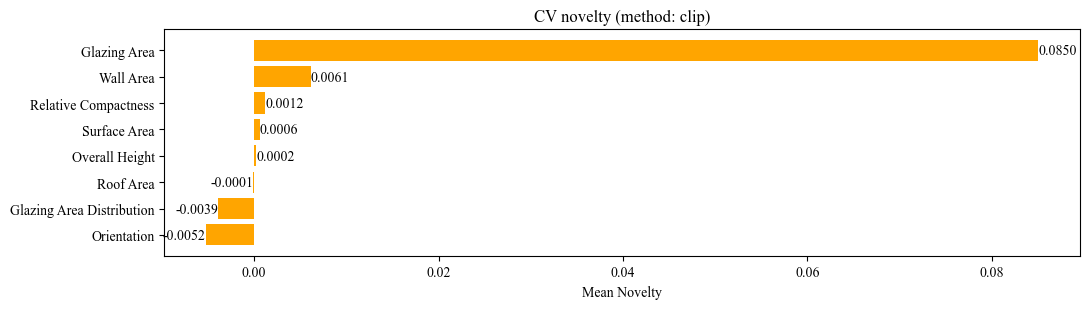

In [26]:
print_cv_novelty(clip_results_higher_degs, X.columns, method="clip")
plot_cv_novelty(clip_results_higher_degs, X.columns, method="clip")

In [27]:
from src.evaluation import novelty_to_df
novelty_df = novelty_to_df(softplus_results_higher_degs,
                           param_softplus_results_higher_degs,
                           clip_results_higher_degs)
novelty_df

softplus           param_softplus            \
                               mean       std           mean       std   
feature                                                                  
Relative Compactness       0.001431  0.000475      -0.000245  0.001927   
Surface Area               0.000987  0.000333       0.000058  0.001042   
Wall Area                  0.004741  0.005614       0.002450  0.012738   
Roof Area                 -0.000101  0.000342      -0.000919  0.000877   
Overall Height             0.000217  0.000092       0.000548  0.000282   
Orientation               -0.003647  0.002159      -0.007788  0.004786   
Glazing Area               0.128728  0.019077       0.294042  0.049863   
Glazing Area Distribution -0.002534  0.004628      -0.004724  0.011229   

                               clip            
                               mean       std  
feature                                        
Relative Compactness       0.001228  0.000690  
Surface Area               0.000620  0.000604  
Wall Area                  0.006113  0.006665  
Roof Area                 -0.000092  0.000365  
Overall Height             0.000240  0.000251  
Orientation               -0.005239  0.002685  
Glazing Area               0.085038  0.024539  
Glazing Area Distribution -0.003877  0.005674